In [45]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

from keras_yamnet import params
from keras_yamnet.yamnet import YAMNet
import keras_yamnet.preprocessing as kp
from keras_yamnet.postprocessing import postprocess_output

import tensorflow as tf

import soundfile as sf
import os
import platform
import time
from tqdm import tqdm
import pickle
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
import h5py
from sklearn.utils import shuffle
from sed_eval.sound_event import EventBasedMetrics, SegmentBasedMetrics
from dataset import gt_conversion_functions as cf
import settings
import importlib
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
importlib.reload(settings)

# print("CUDA available:", torch.cuda.is_available())  # should be True
# print("Wheel CUDA runtime:", torch.version.cuda)     # should be '11.8'
# print("GPU:", torch.cuda.get_device_name(0))

<module 'settings' from '/Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/settings.py'>

In [68]:
# Functions and Classes

class ModifiedModel(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 512)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(512, num_classes)
        # self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.dropout(x)
        x = self.fc2(x)
        # x = self.sigmoid(x)
        return x
    
def save_arrays_to_cache(x, y, cache_file):
    with h5py.File(cache_file, 'w') as f:
        dset_x = f.create_dataset('x', shape=x.shape, dtype=x.dtype)
        dset_y = f.create_dataset('y', shape=y.shape, dtype=y.dtype)
        for i in tqdm(range(x.shape[0]), desc='Saving x to cache'):
            dset_x[i] = x[i]
        for i in tqdm(range(y.shape[0]), desc='Saving y to cache'):
            dset_y[i] = y[i]

def load_arrays_from_cache(cache_file):
    with h5py.File(cache_file, 'r') as f:
        x = f['x'][:]
        y = f['y'][:]
    return x, y

def load_features_and_labels_from_cache(gt_path, audios_folders, base_model, force_reload, apply_filter=False):

    if apply_filter == False:
        filter_name = 'Unfiltered'
    else:
        filter_name = apply_filter

    cache_file = os.path.splitext(gt_path)[0]+ f'_{filter_name}' + '.npz'

    if os.path.exists(cache_file) and not force_reload:
        print(f"Loading cached result from {cache_file} ...")
        x, y = load_arrays_from_cache(cache_file)
    else:
        print(f'Processing and caching in : {cache_file}')
        x, y = load_features_and_array_labels(gt_path, audios_folders, base_model, apply_filter=apply_filter)
        save_arrays_to_cache(x, y, cache_file)

    return x, y


def load_features_and_array_labels(gt_path, audio_folders, base_model, apply_filter=False):
    """
    Load training data from ground truth file and preprocess it.

    Args:
        gt_file (pd.DataFrame): DataFrame containing ground truth data.
    Returns:
        input_array (np.ndarray): Array of preprocessed audio data patches.
        output_array (np.ndarray): Array of target outputs corresponding to the audio data. 
            Contains targets that are one-hot encoded vectors for each class.
    """
    gt_file = pd.read_csv(gt_path, sep='\s+')

    audiofile_to_detection = {}  
    audiofile_to_patches = {}  
    class_to_count = [0 for _ in range(settings.N_CLASSES)]
    n_detections = 0

    for _, row in tqdm(gt_file.iterrows(), total=len(gt_file), desc='Loading gt'):
        audiofile = row['filename']

        starttime = row['start_time']
        endtime = row['end_time']
        class_idx = row['class']

        patch_index_start = cf.second_to_index(starttime)
        patch_index_end = cf.second_to_index(endtime)

        class_to_count[class_idx] += 1

        n_detections += 1

        if audiofile not in audiofile_to_detection:
            audio_path = None
            for audio_folder in audio_folders:
                candidate = os.path.join(audio_folder, audiofile)
                if os.path.exists(candidate):
                    audio_path = candidate
                    break

            if audio_path is None:
                raise FileNotFoundError(f'Audio file {audiofile} not found in any of the specified folders.')

            audio_wave, sample_rate = sf.read(audio_path)
            data_patches, _ = kp.preprocess_input(audio_wave, sample_rate, apply_filter=apply_filter)
            audiofile_to_patches[audiofile] = data_patches

            pred = np.zeros((len(data_patches), settings.N_CLASSES), dtype=np.float32)
            pred[patch_index_start:patch_index_end+1, class_idx] = settings.GT_CONFIDENCE
            audiofile_to_detection[audiofile] = pred

        else:
            audiofile_to_detection[audiofile][patch_index_start:patch_index_end, class_idx] = settings.GT_CONFIDENCE

    print(f'Number of instances of class Aircraft: {class_to_count[1]} \n Number of instances of class No aircraft: {class_to_count[0]} \n Total number of instances: {n_detections}')
    
    input_array = []
    output_array = []

    for audiofile in audiofile_to_detection: 
        data_patches = audiofile_to_patches[audiofile]
        pred = audiofile_to_detection[audiofile]

        input_array.append(data_patches)
        output_array.append(pred)
        
    input_array = np.concatenate(input_array, axis=0)  # shape: (num_patches, PATCH_FRAMES, n_bands)
    output_array = np.concatenate(output_array, axis=0)  # shape: (num_patches, N_CLASSES)
    print(f"output_array shape: {np.array(output_array).shape}")

    input_embedding = base_model.predict(input_array, verbose=1) # If keras model
    
    return input_embedding, output_array

def visualize_and_save_history(history, timestamp):
    """
    Visualize training history.
    
    Args:
        history (tf.keras.callbacks.History): History object containing training metrics.
    """

    fig, axs = plt.subplots(2, 1, figsize=(12, 10))

    # Loss subplot
    axs[0].plot(history.history['loss'], label='Training Loss', color='#003366')  # Dark blue
    axs[0].plot(history.history['val_loss'], label='Validation Loss', color='#66b3ff')  # Light blue
    axs[0].set_title('Training and Validation Loss')
    axs[0].set_xlabel('Epochs')
    axs[0].set_ylabel('Loss')
    axs[0].set_ylim(0, 1.5)
    axs[0].legend()
    axs[0].grid()

    # F1-SCORE  subplot
    axs[1].plot(history.history['f1_score'], label='Training f1-score', color='#006400')  # Dark green
    axs[1].plot(history.history['val_f1_score'], label='Validation f1-score', color='#90ee90')  # Light green
    axs[1].set_title('Training and Validation f1-score')
    axs[1].set_xlabel('Epochs')
    axs[1].set_ylabel('f1-score')
    axs[1].set_ylim(0, 1)
    axs[1].legend()
    axs[1].grid()

    plt.tight_layout()
    plt.show()

    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestamp}', exist_ok=True)
    fig.savefig(f'history/{timestamp}/history.png')

def predictions_to_event_list(predictions):
    """
    Convert model predictions to a list of detected events compatible with sed_eval.
    Assumes predictions are binary (0 or 1) for each class at each segment.
    """
    output = []
    predictions = np.array(predictions)
    num_segments, num_classes = predictions.shape

    for i in range(num_segments):
        for class_idx, score in enumerate(predictions[i]):
            if score == 1:
                output.append({
                    'file': 'an_audio',
                    'event_label': settings.CLASS_NAMES[class_idx],
                    'onset': i * params.PATCH_WINDOW_SECONDS,
                    'offset': (i + 1) * params.PATCH_WINDOW_SECONDS
                })

    return output

def print_metrics(metrics, title):
    print(f"\n{title}")
    overall = metrics['overall']
    print(f"  F1: {overall['f_measure']['f_measure']:.3f} | Precision: {overall['f_measure']['precision']:.3f} | Recall: {overall['f_measure']['recall']:.3f}")
    print(f"  Error Rate: {overall['error_rate']['error_rate']:.3f}")
    if 'accuracy' in overall and overall['accuracy']:
        acc = overall['accuracy'].get('accuracy', None)
        if acc is not None:
            print(f"  Accuracy: {acc:.3f}")
    print("  Class-wise F1:")
    for cls, vals in metrics['class_wise'].items():
        f1 = vals['f_measure']['f_measure']
        print(f"    {cls}: {f1:.3f}")

def get_data_from_dict(data_dict, base_model, force_reload= settings.FORCE_RELOAD_TRAIN, apply_filter=False):
    X = None
    y = None

    for gt_path, audios_folders in data_dict.items():

        X_temp, y_temp = load_features_and_labels_from_cache(gt_path, audios_folders, base_model, force_reload, apply_filter=apply_filter)

        if X is None and y is None:
            X = X_temp
            y = y_temp
        else:
            X = np.concatenate((X, X_temp), axis=0)
            y = np.concatenate((y, y_temp), axis=0)

    X, y = shuffle(X, y, random_state=42)

    return X, y

def get_device():
    # 1) NVIDIA GPU (Windows/Linux/macOS w/ eGPU): fastest if available
    if torch.cuda.is_available():
        return torch.device("cuda"), "cuda"

    # 2) Apple Silicon GPU (macOS M1/M2/M3)
    if platform.system() == "Darwin" and torch.backends.mps.is_available():
        # Optional: allow silent CPU fallback for unsupported ops on MPS
        os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
        return torch.device("mps"), "mps"

    # 3) DirectML (Windows + AMD/Intel/NVIDIA via the 'torch-directml' package)
    #    pip install torch-directml   (import torch_directml)  -> a separate package
    try:
        if platform.system() == "Windows":
            import torch_directml  # noqa: F401
            dml = torch_directml.device()
            return dml, "directml"
    except Exception:
        pass

    # 4) CPU fallback (works everywhere)
    return torch.device("cpu"), "cpu"

def save_sed_metric(filename, metric, timestr):
    with open(f'history/{timestr}/{filename}.pk1', "wb") as f:
        pickle.dump(metric, f)

def load_sed_metric(filepath):
    with open(filepath, "rb") as f:
        metric = pickle.load(f)
    return metric

def train_model(X_embedding, y_embedding, model, device, title=None, save=True, val_split=0.2):
    
    # Prepare PyTorch datasets and loaders
    X_tensor = torch.tensor(X_embedding, dtype=torch.float32).to(device)
    y_tensor = torch.tensor(y_embedding, dtype=torch.float32).to(device)
    # dataset = torch.utils.data.TensorDataset(X_tensor, y_tensor)
    # train_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

    # Validation split
    val_split = getattr(settings, "VAL_SIZE", val_split)
    num_val = int(len(X_tensor) * val_split)
    indices = np.arange(len(X_tensor.cpu()))
    np.random.shuffle(indices)
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]

    X_val_tensor = X_tensor[val_indices]
    y_val_tensor = y_tensor[val_indices]
    val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

    X_train_tensor = X_tensor[train_indices]
    y_train_tensor = y_tensor[train_indices]
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=False)

    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    patience = 30
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train(True)
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            best_epoch = epoch
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    timestr = time.strftime("%Y%m%d-%H%M%S")
    

    # SAVE MODEL AND LOSS PLOT
    if save:
    
        os.makedirs('history', exist_ok=True)
        os.makedirs(f'history/{timestr}', exist_ok=True)
        torch.save(model, f'history/{timestr}/modified_model_{best_epoch}.pt')

        print(f'Model saved to history/{timestr}/modified_model_{best_epoch}.pt')
        
        plt.plot(train_losses, label='Train Loss')
        plt.plot(val_losses, label='Val Loss')
        plt.legend()
        plt.title(title)
        pdf_path = f'history/{timestr}/loss_plot.pdf'
        plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
        print(f'Saved loss plot in vector PDF: {pdf_path}')

    return model, train_losses, val_losses

def plot_losses_discrete(losses_by_snr, title="Loss per Epoch (discrete SNR colors)", save_path=None, snrs=None, max_epochs=None, y_lim=100):
    fig, ax = plt.subplots(figsize=(10, 6))
    snrs = sorted(losses_by_snr.keys())
    cmap_name = "Reds"
    cmap = plt.cm.RdYlGn
    norm = Normalize(vmin=min(snrs), vmax=max(snrs))
    color_for = {snr: cmap(norm(snr)) for snr in snrs}

    for snr, (train_losses, val_losses) in sorted(losses_by_snr.items()):
        if max_epochs:
            train_losses = train_losses[:max_epochs]
            val_losses = val_losses[:max_epochs]
        c = color_for.get(snr, "k")
        xt = np.arange(1, len(train_losses) + 1)
        xv = np.arange(1, len(val_losses) + 1)
        ax.plot(xt, train_losses, color=c, linewidth=0.5)
        ax.plot(xv, val_losses,  color=c, linestyle="--", linewidth=0.5)

    # plt.axhline(y=0.1395, color='b', linestyle='-')
    # plt.axhline(y=0.1136, color='tab:orange', linestyle='-')
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, y_lim)

    # Legend 1: color ↔ SNR (inside the plot)
    color_handles = [Line2D([0], [0], color=color_for[s], lw=3, label=f"SNR {s}") for s in sorted(losses_by_snr)]
    leg1 = ax.legend(handles=color_handles, loc="upper right", frameon=True, title="SNR")
    ax.add_artist(leg1)

    # Legend 2: line style (train vs val)
    style_handles = [
        Line2D([0], [0], color="black", linestyle="-",  label="Train"),
        Line2D([0], [0], color="black", linestyle="--", label="Validation"),
    ]
    leg_style = ax.legend(handles=style_handles, loc="lower right", frameon=True, title="Line style")
    ax.add_artist(leg_style)

    # # Legend 3: baseline model loss
    # model_handles = [
    #     Line2D([0], [0], color="b",  label="Train"),
    #     Line2D([0], [0], color="tab:orange", label="Validation"),
    # ]
    # leg_model = ax.legend(handles=model_handles, loc="upper left", frameon=True, title="Baseline model preformance")
    # ax.add_artist(leg_model)
    
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches="tight")
        print("Saved:", save_path)
    else:
        plt.show()

    

In [5]:
# Load baseline model

yamnet_model_name = 'keras_yamnet/yamnet.h5'
yamnet_model = YAMNet(weights=yamnet_model_name)
base_model = tf.keras.Model(
    inputs=yamnet_model.input,
    outputs=yamnet_model.get_layer('global_average_pooling2d').output
)
yamnet_model.trainable = False
base_model.trainable = False

In [25]:
# Load dataset
importlib.reload(settings) 


X_embeddings_env, y_env = get_data_from_dict(settings.data_pair_env, base_model)
X_embeddings_train, y_train = get_data_from_dict(settings.data_pairs_train, base_model)
X_embeddings_test, y_test = get_data_from_dict(settings.data_pairs_test, base_model)

Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/env_audio_gt_Unfiltered.npz ...
Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_train_Unfiltered.npz ...
Loading cached result from /Users/ingeborgborhaug/Skole/9.semester (harddrive)/Prosjektoppgave/sound-event-detection-aircrafts/dataset/AeroSonicDB/gt_test_Unfiltered.npz ...


Using device: mps
Epoch 1/300 | Train Loss: 0.3706 | Val Loss: 0.3084
Epoch 2/300 | Train Loss: 0.3221 | Val Loss: 0.2968
Epoch 3/300 | Train Loss: 0.3088 | Val Loss: 0.2920
Epoch 4/300 | Train Loss: 0.3024 | Val Loss: 0.2824
Epoch 5/300 | Train Loss: 0.2929 | Val Loss: 0.2762
Epoch 6/300 | Train Loss: 0.2903 | Val Loss: 0.2804
Epoch 7/300 | Train Loss: 0.2833 | Val Loss: 0.2704
Epoch 8/300 | Train Loss: 0.2808 | Val Loss: 0.2875
Epoch 9/300 | Train Loss: 0.2812 | Val Loss: 0.2740
Epoch 10/300 | Train Loss: 0.2709 | Val Loss: 0.2633
Epoch 11/300 | Train Loss: 0.2666 | Val Loss: 0.2636
Epoch 12/300 | Train Loss: 0.2659 | Val Loss: 0.2649
Epoch 13/300 | Train Loss: 0.2616 | Val Loss: 0.2826
Epoch 14/300 | Train Loss: 0.2563 | Val Loss: 0.2673
Epoch 15/300 | Train Loss: 0.2529 | Val Loss: 0.2569
Epoch 16/300 | Train Loss: 0.2530 | Val Loss: 0.2582
Epoch 17/300 | Train Loss: 0.2524 | Val Loss: 0.2553
Epoch 18/300 | Train Loss: 0.2466 | Val Loss: 0.2611
Epoch 19/300 | Train Loss: 0.2460 | V

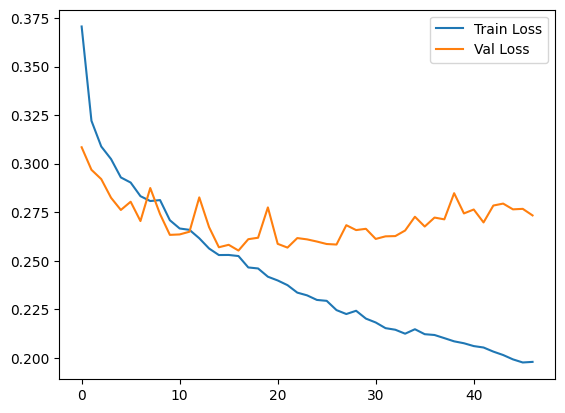

In [ ]:
# Load data and train the model

if __name__ == "__main__":

    device, device_type = get_device()
    print(f"Using device: {device_type}")
    
    model = ModifiedModel(input_dim=X_embeddings_train.shape[1], num_classes=settings.N_CLASSES).to(device)

    trained_model , _, _ = train_model(X_embeddings_train, y_train, model, device)
    # train_model(X_embeddings_env, y_env, trained_model, device)


In [81]:
# Load unfiltered data
importlib.reload(settings) 
importlib.reload(kp)
 
X_embeddings_mix_snr1, y_mix_snr1 = get_data_from_dict(settings.data_pair_mix_snr1, base_model)
X_embeddings_mix_snr5, y_mix_snr5 = get_data_from_dict(settings.data_pair_mix_snr5, base_model)
X_embeddings_mix_snr10, y_mix_snr10 = get_data_from_dict(settings.data_pair_mix_snr10, base_model)
X_embeddings_mix_snr15, y_mix_snr15 = get_data_from_dict(settings.data_pair_mix_snr15, base_model)
X_embeddings_mix_snr20, y_mix_snr20 = get_data_from_dict(settings.data_pair_mix_snr20, base_model)

Loading cached result from dataset/synthetic_data/snr1_gt_A2-0002_OPT_G_002_0001_Tr2_Unfiltered.npz ...
Loading cached result from dataset/synthetic_data/snr5_gt_A2-0002_OPT_G_002_0001_Tr2_Unfiltered.npz ...
Loading cached result from dataset/synthetic_data/snr10_gt_A2-0002_OPT_G_002_0001_Tr2_Unfiltered.npz ...
Loading cached result from dataset/synthetic_data/snr15_gt_A2-0002_OPT_G_002_0001_Tr2_Unfiltered.npz ...
Loading cached result from dataset/synthetic_data/snr20_gt_A2-0002_OPT_G_002_0001_Tr2_Unfiltered.npz ...


In [98]:
# Load band-pass filtered data
importlib.reload(kp) 

X_embeddings_mix_snr1_bp, y_mix_snr1_bp = get_data_from_dict(settings.data_pair_mix_snr1, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_mix_snr5_bp, y_mix_snr5_bp = get_data_from_dict(settings.data_pair_mix_snr5, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_mix_snr10_bp, y_mix_snr10_bp = get_data_from_dict(settings.data_pair_mix_snr10, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_mix_snr15_bp, y_mix_snr15_bp = get_data_from_dict(settings.data_pair_mix_snr15, base_model, force_reload= True, apply_filter="bandpass")
X_embeddings_mix_snr20_bp, y_mix_snr20_bp = get_data_from_dict(settings.data_pair_mix_snr20, base_model, force_reload= True, apply_filter="bandpass")


Processing and caching in : dataset/synthetic_data/snr1_gt_A2-0002_OPT_G_002_0001_Tr2_bandpass.npz


Loading gt: 100%|██████████| 12/12 [00:00<00:00, 12.27it/s]


Number of instances of class Aircraft: 4 
 Number of instances of class No aircraft: 8 
 Total number of instances: 12
output_array shape: (1904, 2)
60/60 [==============================] - 2s 29ms/step


Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 49673.78it/s]


Processing and caching in : dataset/synthetic_data/snr5_gt_A2-0002_OPT_G_002_0001_Tr2_bandpass.npz


...

Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 39693.01it/s]


Processing and caching in : dataset/synthetic_data/snr20_gt_A2-0002_OPT_G_002_0001_Tr2_bandpass.npz


Loading gt: 100%|██████████| 12/12 [00:00<00:00, 16.14it/s]


Number of instances of class Aircraft: 4 
 Number of instances of class No aircraft: 8 
 Total number of instances: 12
output_array shape: (1904, 2)
60/60 [==============================] - 2s 31ms/step


Saving y to cache: 100%|██████████| 1904/1904 [00:00<00:00, 50938.96it/s]


In [84]:
# Load model

path = "history/20251115-120010/modified_model_16.pt"  
device, _ = get_device()
synthetic_data_folder = "dataset/synthetic_data/part1"

model = torch.load(path, map_location=device, weights_only=False)

In [85]:
# Train on unfiltered data
_, train_losses1, val_losses1 = train_model(X_embeddings_mix_snr1, y_mix_snr1, model, device, title= f'SNR {1}', save=False)
_, train_losses5, val_losses5 = train_model(X_embeddings_mix_snr5, y_mix_snr5, model, device, title= f'SNR {5}', save=False)
_, train_losses10, val_losses10 = train_model(X_embeddings_mix_snr10, y_mix_snr10, model, device, title= f'SNR {10}', save=False)
_, train_losses15, val_losses15 = train_model(X_embeddings_mix_snr15, y_mix_snr15, model, device, title= f'SNR {15}', save=False)
_, train_losses20, val_losses20 = train_model(X_embeddings_mix_snr20, y_mix_snr20, model, device, title= f'SNR {20}', save=False)


Epoch 1/300 | Train Loss: 8.5973 | Val Loss: 1.8459
Epoch 2/300 | Train Loss: 1.5294 | Val Loss: 0.9877
Epoch 3/300 | Train Loss: 0.7997 | Val Loss: 0.7413
Epoch 4/300 | Train Loss: 0.6736 | Val Loss: 0.7309
Epoch 5/300 | Train Loss: 0.6552 | Val Loss: 0.7265
Epoch 6/300 | Train Loss: 0.6448 | Val Loss: 0.7161
Epoch 7/300 | Train Loss: 0.6487 | Val Loss: 0.7124
Epoch 8/300 | Train Loss: 0.6406 | Val Loss: 0.7115
Epoch 9/300 | Train Loss: 0.6318 | Val Loss: 0.7129
Epoch 10/300 | Train Loss: 0.6420 | Val Loss: 0.7097
Epoch 11/300 | Train Loss: 0.6362 | Val Loss: 0.7085
Epoch 12/300 | Train Loss: 0.6273 | Val Loss: 0.7029
Epoch 13/300 | Train Loss: 0.6231 | Val Loss: 0.7024
Epoch 14/300 | Train Loss: 0.6263 | Val Loss: 0.7009
Epoch 15/300 | Train Loss: 0.6210 | Val Loss: 0.6937
Epoch 16/300 | Train Loss: 0.6206 | Val Loss: 0.6887
Epoch 17/300 | Train Loss: 0.6049 | Val Loss: 0.6767
Epoch 18/300 | Train Loss: 0.5968 | Val Loss: 0.6614
Epoch 19/300 | Train Loss: 0.5892 | Val Loss: 0.6716
Ep

In [99]:
# Train with filtered data
_, train_losses1_bp, val_losses1_bp = train_model(X_embeddings_mix_snr1_bp, y_mix_snr1_bp, model, device, title= f'SNR {1}', save=False)
_, train_losses5_bp, val_losses5_bp = train_model(X_embeddings_mix_snr5_bp, y_mix_snr5_bp, model, device, title= f'SNR {5}', save=False)
_, train_losses10_bp, val_losses10_bp = train_model(X_embeddings_mix_snr10_bp, y_mix_snr10_bp, model, device, title= f'SNR {10}', save=False)
_, train_losses15_bp, val_losses15_bp = train_model(X_embeddings_mix_snr15_bp, y_mix_snr15_bp, model, device, title= f'SNR {15}', save=False)
_, train_losses20_bp, val_losses20_bp = train_model(X_embeddings_mix_snr20_bp, y_mix_snr20_bp, model, device, title= f'SNR {20}', save=False)


Epoch 1/300 | Train Loss: 2.5104 | Val Loss: 1.7593
Epoch 2/300 | Train Loss: 1.4515 | Val Loss: 1.1386
Epoch 3/300 | Train Loss: 1.0437 | Val Loss: 0.9010
Epoch 4/300 | Train Loss: 0.8108 | Val Loss: 0.8115
Epoch 5/300 | Train Loss: 0.7458 | Val Loss: 0.7716
Epoch 6/300 | Train Loss: 0.7245 | Val Loss: 0.7549
Epoch 7/300 | Train Loss: 0.6910 | Val Loss: 0.7383
Epoch 8/300 | Train Loss: 0.6875 | Val Loss: 0.7138
Epoch 9/300 | Train Loss: 0.6525 | Val Loss: 0.6995
Epoch 10/300 | Train Loss: 0.6589 | Val Loss: 0.6887
Epoch 11/300 | Train Loss: 0.6380 | Val Loss: 0.6790
Epoch 12/300 | Train Loss: 0.6067 | Val Loss: 0.6753
Epoch 13/300 | Train Loss: 0.6061 | Val Loss: 0.6743
Epoch 14/300 | Train Loss: 0.6029 | Val Loss: 0.6644
Epoch 15/300 | Train Loss: 0.5887 | Val Loss: 0.6588
Epoch 16/300 | Train Loss: 0.5993 | Val Loss: 0.6519
Epoch 17/300 | Train Loss: 0.5898 | Val Loss: 0.6548
Epoch 18/300 | Train Loss: 0.5922 | Val Loss: 0.6504
Epoch 19/300 | Train Loss: 0.5780 | Val Loss: 0.6445
Ep

Saved: history/loss_witout_wiener.pdf
Saved: history/loss_with_wiener.pdf


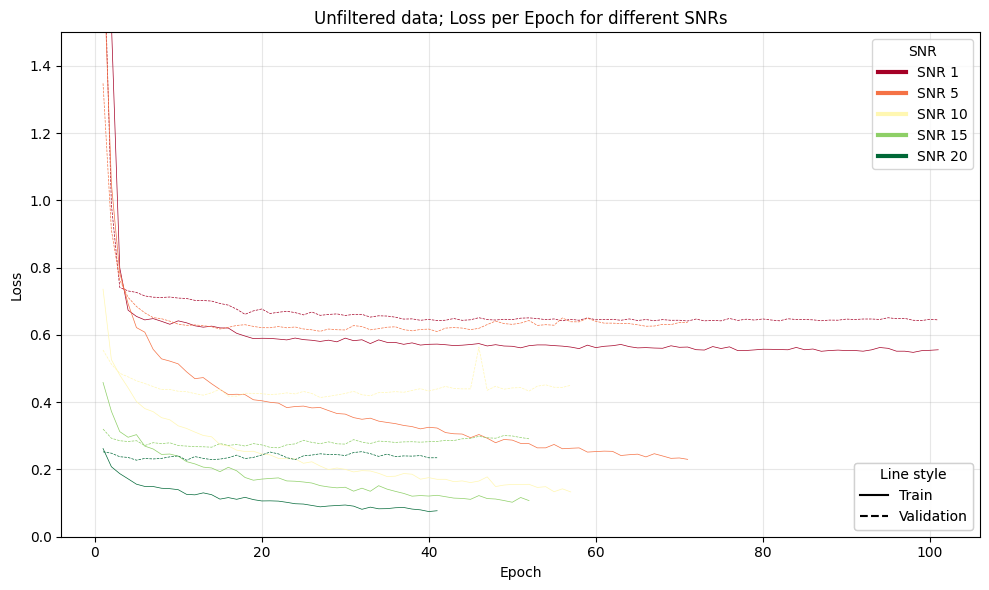

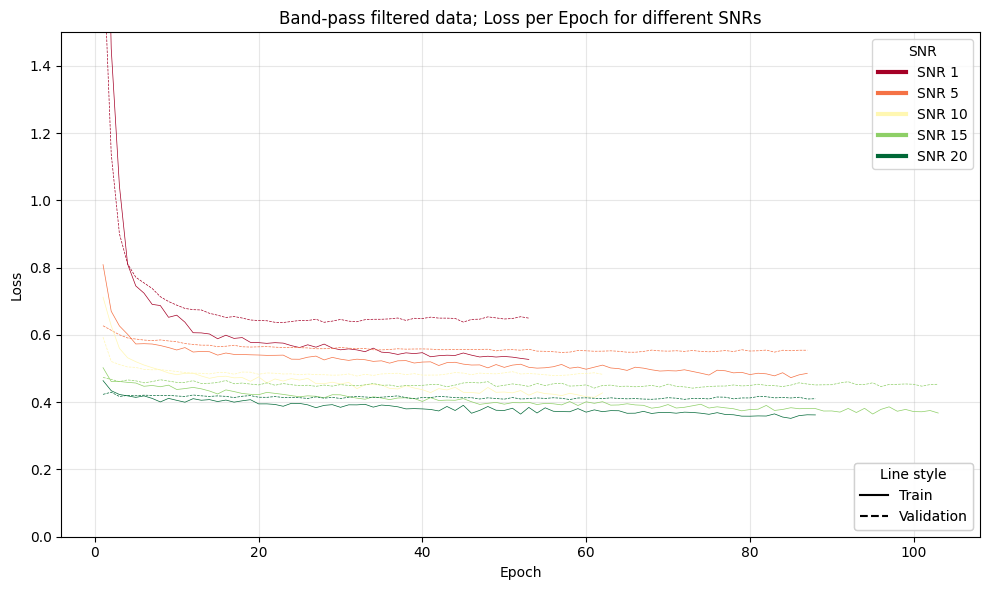

In [100]:
# Plot all losses together

unfiltered_losses_by_snr = {
    1:  (train_losses1,  val_losses1),
    5: (train_losses5, val_losses5),
    10: (train_losses10, val_losses10),
    15: (train_losses15, val_losses15),
    20:  (train_losses20,  val_losses20)
}

filtered_losses_by_snr = {
    1:  (train_losses1_bp,  val_losses1_bp),
    5: (train_losses5_bp, val_losses5_bp),
    10: (train_losses10_bp, val_losses10_bp),
    15: (train_losses15_bp, val_losses15_bp),
    20:  (train_losses20_bp,  val_losses20_bp)
}

color_for = {1: "tab:blue", 5: "tab:orange", 10: "tab:green", 15: "tab:red", 20: "tab:purple"}

# Call it
plot_losses_discrete(unfiltered_losses_by_snr, title="Unfiltered data; Loss per Epoch for different SNRs", save_path="history/loss_witout_wiener.pdf", max_epochs=300, y_lim=1.5)
plot_losses_discrete(filtered_losses_by_snr, title="Band-pass filtered data; Loss per Epoch for different SNRs", save_path="history/loss_with_wiener.pdf", max_epochs=300, y_lim=1.5)

In [44]:
# Test and evaluate the model

model.eval()
X_test_tensor = torch.tensor(X_embeddings_test, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_test = model(X_test_tensor).cpu().numpy()
y_pred_test = postprocess_output(y_pred_test)  # If needed

X_env_tensor = torch.tensor(X_embeddings_env, dtype=torch.float32).to(device)
with torch.no_grad():
    y_pred_env = model(X_env_tensor).cpu().numpy()
y_pred_env = postprocess_output(y_pred_env)

event_metrics = EventBasedMetrics(event_label_list=settings.CLASS_NAMES, t_collar=params.PATCH_WINDOW_SECONDS)
segment_metrics = SegmentBasedMetrics(event_label_list=settings.CLASS_NAMES, time_resolution=params.PATCH_WINDOW_SECONDS)

predicted_event_list_test = predictions_to_event_list(y_pred_test)
reference_event_list_test = predictions_to_event_list(y_test)
predicted_event_list_env = predictions_to_event_list(y_pred_env)
reference_event_list_env = predictions_to_event_list(y_env)
print("Data processed for evaluation...")
print("Predicted event list test length:", len(predicted_event_list_test))
print("Reference event list test length:", len(reference_event_list_test))
print("Predicted event list env length:", len(predicted_event_list_env))
print("Reference event list env length:", len(reference_event_list_env))

event_metrics.evaluate(predicted_event_list_test, reference_event_list_test)
segment_metrics.evaluate(predicted_event_list_test, reference_event_list_test)

save_sed_metric('Event-based-dataset', event_metrics.results(), timestr)
save_sed_metric('Segment-based-dataset', segment_metrics.results(), timestr)
print_metrics(event_metrics.results(), "Event-based (Test set)")
print_metrics(segment_metrics.results(), "Segment-based (Test set)")

event_metrics.evaluate(predicted_event_list_env, reference_event_list_env)
segment_metrics.evaluate(predicted_event_list_env, reference_event_list_env)

save_sed_metric('Event-based-env-dataset', event_metrics.results(), timestr)
save_sed_metric('Segment-based-env-dataset', segment_metrics.results(), timestr)
print_metrics(event_metrics.results(), "Event-based (Environment set)")
print_metrics(segment_metrics.results(), "Segment-based (Environment set)")

Data processed for evaluation...
Predicted event list test length: 23856
Reference event list test length: 32488
Predicted event list env length: 41910
Reference event list env length: 76002


KeyboardInterrupt: 

In [ ]:
# Load metrics if desired

event_metric = load_sed_metric(f'history/251104-162942/Event-based-env-dataset.pk1')
segment_metric = load_sed_metric(f'history/251104-162942/Segment-based-env-dataset.pk1')

print_metrics(event_metrics.results(), "Event-based (Env set)")
print_metrics(segment_metrics.results(), "Segment-based (Env set)")


FileNotFoundError: [Errno 2] No such file or directory: 'history/251104-162942/Event-based-env-dataset.pk1'

In [ ]:
# Old script for training, made into fucntion train_model()

""" # Prepare PyTorch datasets and loaders
    X_train_tensor = torch.tensor(X_embeddings_train, dtype=torch.float32).to(device)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32).to(device)
    print("y_train_tensor shape:", y_train_tensor.shape)
    train_dataset = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

    # Validation split
    val_split = getattr(settings, "VAL_SIZE", 0.2)
    num_val = int(len(X_train_tensor) * val_split)
    indices = np.arange(len(X_train_tensor.cpu()))
    np.random.shuffle(indices)
    val_indices = indices[:num_val]
    train_indices = indices[num_val:]
    X_val_tensor = X_train_tensor[val_indices]
    y_val_tensor = y_train_tensor[val_indices]
    val_dataset = torch.utils.data.TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

    #criterion = nn.BCELoss()
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 300
    patience = 20
    best_loss = float('inf')
    epochs_no_improve = 0
    best_state = None
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for inputs, targets in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
        epoch_loss = running_loss / len(train_loader.dataset)
        train_losses.append(epoch_loss)

        # Validation
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)
        val_loss /= len(val_loader.dataset)
        val_losses.append(val_loss)
        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_loss:.4f} | Val Loss: {val_loss:.4f}")

        # Early stopping
        if val_loss < best_loss:
            best_loss = val_loss
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

    model.load_state_dict(best_state)

    # SAVE MODEL 
    timestr = time.strftime("%Y%m%d-%H%M%S")
    os.makedirs('history', exist_ok=True)
    os.makedirs(f'history/{timestr}', exist_ok=True)
    torch.save(model, f'history/{timestr}/modified_model.pt')

    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses, label='Val Loss')
    plt.legend()
    plt.show()
    pdf_path = f'history/{timestr}/loss_plot.pdf'
    plt.savefig(pdf_path, format='pdf', bbox_inches='tight')
    print(f'Saved vector PDF: {pdf_path}') """